Empezamos con los imports y la configuración inicial:

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt #librería base de visualización en python. plt es una convención universal, un alias
import seaborn as sns #Está construido encima de matplotlib, lo hace más bonito y más fácil. El alias sns viene del personaje de la serie The Wes Wing (chiste interno del creador)
from src.transform import load_raw, clean, engineer_features
from src.queries import (
    top_roles_by_salary,
    work_setting_distribution,
    offers_by_year,
    salary_by_experience,
    remote_trend_by_year
)

# Configuración visual global
sns.set_theme(style='whitegrid') #Establece el estilo visual global para todos los gráficos del notebook. "whitegrid" significa fondo blanco con lineas de cuadriculas grises
plt.rcParams['figure.figsize'] = (10, 6) #Parámetros globales de matplotlib. Con esta línea decimos que todos los gráficos midan tal y tal.

# Cargamos el dataframe
df = load_raw('../data/raw/jobs_in_data.csv')
df = clean(df)
df = engineer_features(df)

print('Datos cargados:', df.shape)

Datos cargados: (9355, 16)


Antes de hacer los gráficos, creamos la carpeta donde los guardaremos:

In [2]:
import os
os.makedirs('../data/processed/charts', exist_ok=True) #exist_ok significa que si la carpeta ya existe no da error, simplemente no hace nada
print('Carpeta creada')

Carpeta creada


Vamos con el primer gráfico: TOP 10 DE ROLES POR SALARIO MEDIO

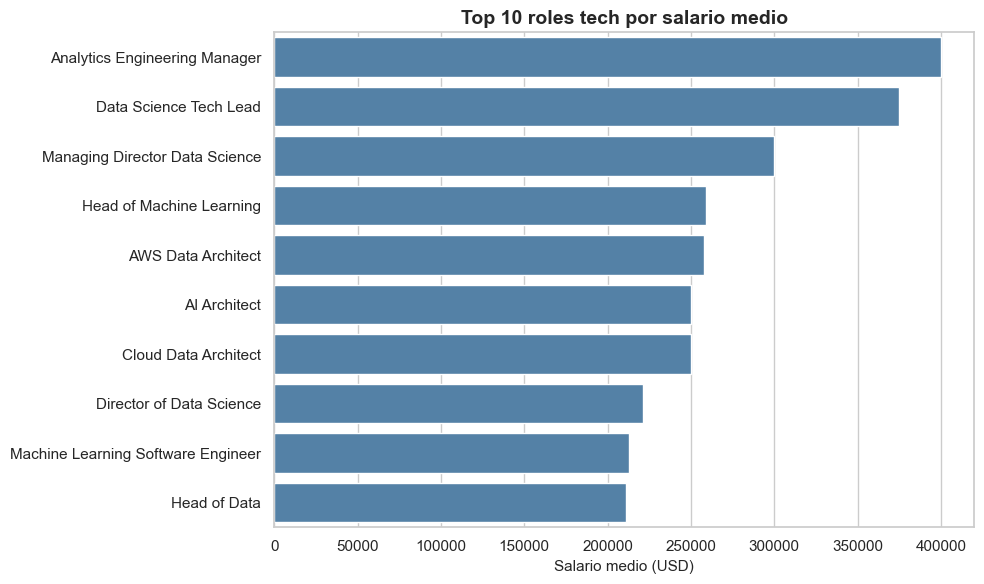

In [3]:
# Obtenemos los datos
data = top_roles_by_salary(df)

# Creamos la figura
fig, ax = plt.subplots() #Crea el lienzo y los ejes. El lienzo es el espacio total, los ejes son donde se dibuja el gráfico. Siempre prabajamos con ax para controlar exactamente qué gráfico estamos modificando

# Dibujamos el gráfico de barras horizontal
sns.barplot(data=data, x='avg_salary', y='job_title', ax=ax, color='steelblue') #Dibuja las barras . x es el valor numérico, y es la etiqueta. Al ser horizontal queda mejor cuando los nombres son largos.

# Título y etiquetas
ax.set_title('Top 10 roles tech por salario medio', fontsize=14, fontweight='bold')
ax.set_xlabel('Salario medio (USD)', fontsize=11)
ax.set_ylabel('')

# Guardamos
plt.tight_layout() #Ajusta automáticamente los márgenes para que nada se corte
plt.savefig('../data/processed/charts/top_roles.png', dpi=150, bbox_inches='tight') #Guarda la imagen. dpi= es la resolución. bbox_inches evita que se corten los bordes.
plt.show()

Segundo gráfico: DISTRIBUCIÓN DE MODALIDAD DE TRABAJO

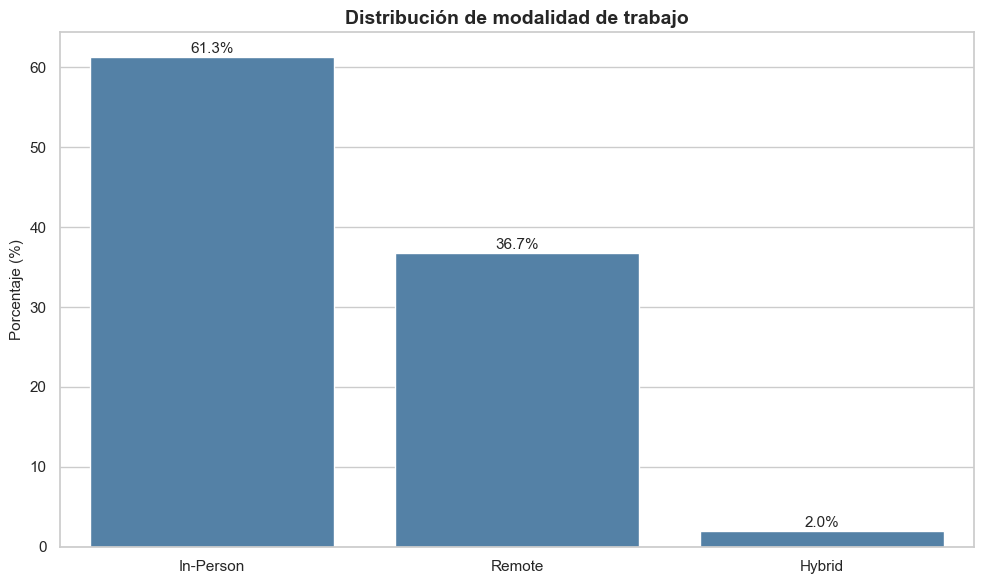

In [4]:
# Obtenemos los datos
data = work_setting_distribution(df)

# Creamos la figura
fig, ax = plt.subplots()

# Gráfico de barras vertical
sns.barplot(data=data, x='work_setting', y='percentage', ax=ax, color='steelblue')

# Título y etiquetas
ax.set_title('Distribución de modalidad de trabajo', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Porcentaje (%)', fontsize=11)

# Añadimos el porcentaje encima de cada barra con un bucle for
for i, row in data.iterrows():
    ax.text(i, row['percentage'] + 0.5, f"{row['percentage']}%",  #escribe texto en coordenadas concretas del gráfico
            ha='center', fontsize=11) #Lo centra horizontalmente

# Guardamos
plt.tight_layout()
plt.savefig('../data/processed/charts/work_setting.png', dpi=150, bbox_inches='tight')
plt.show()

Tercer gráfico: EVOLUCIÓN DE OFERTAS POR AÑO

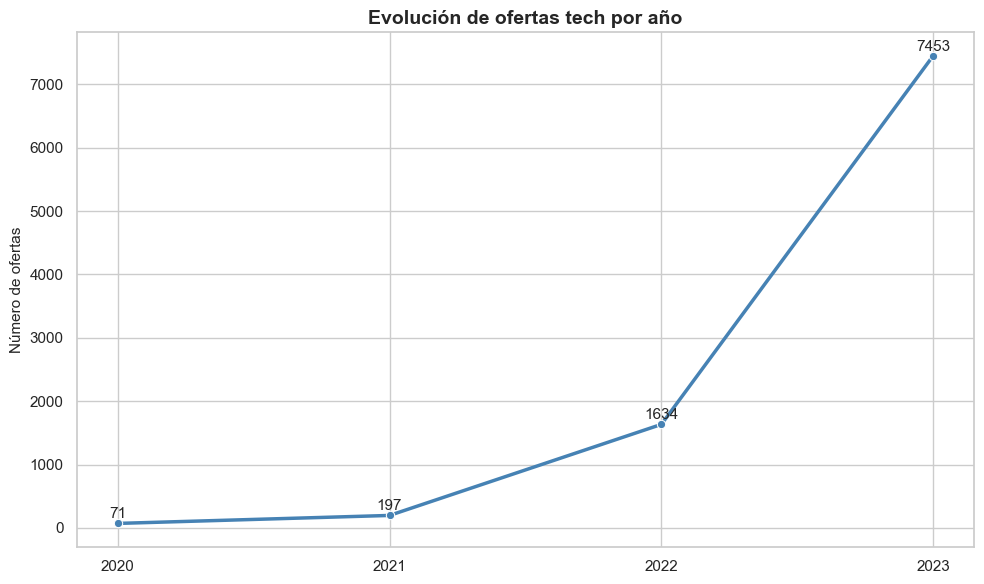

In [5]:
# Obtenemos los datos
data = offers_by_year(df)

# Creamos la figura
fig, ax = plt.subplots()

# Gráfico de línea
sns.lineplot(data=data, x='work_year', y='total_offers', ax=ax, 
             marker='o', linewidth=2.5, color='steelblue') #marker='0' añade un punto en cada año

# Título y etiquetas
ax.set_title('Evolución de ofertas tech por año', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Número de ofertas', fontsize=11)

# Marcamos los valores en cada punto
for _, row in data.iterrows():
    ax.text(row['work_year'], row['total_offers'] + 80, 
            str(int(row['total_offers'])), ha='center', fontsize=11)

# Forzamos que el eje X muestre solo años enteros, sin esto, matplotlib podría añadir valores intermedios como 2021,5
ax.set_xticks(data['work_year'])

# Guardamos
plt.tight_layout()
plt.savefig('../data/processed/charts/trend_by_year.png', dpi=150, bbox_inches='tight')
plt.show()

Cuarto gráfico: SALARIO MEDIO POR NIVEL DE EXPERIENCIA

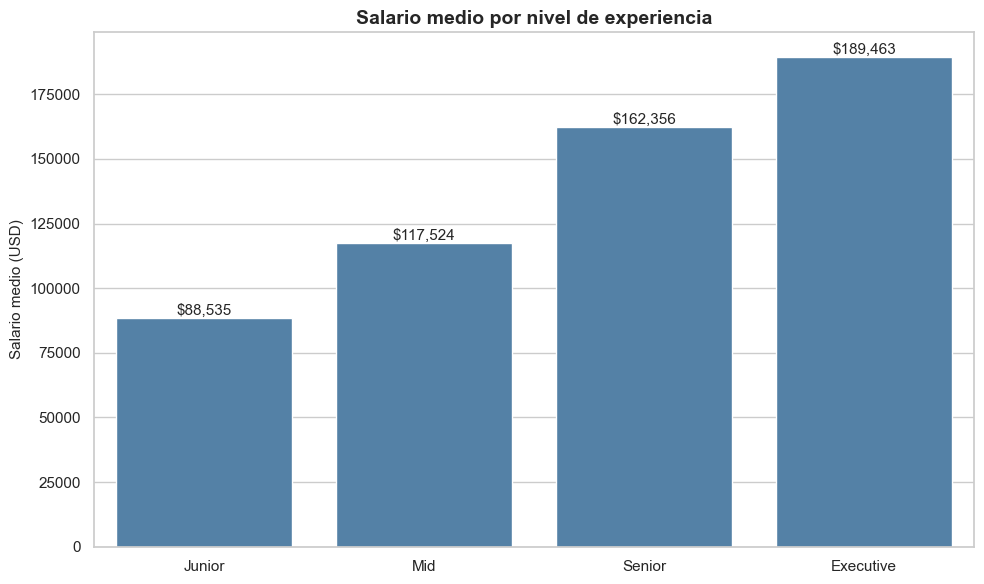

In [6]:
# Obtenemos los datos
data = salary_by_experience(df)

# Creamos la figura
fig, ax = plt.subplots()

# Gráfico de barras vertical
sns.barplot(data=data, x='experience_group', y='avg_salary', ax=ax, color='steelblue')

# Título y etiquetas
ax.set_title('Salario medio por nivel de experiencia', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Salario medio (USD)', fontsize=11)

# Añadimos el valor encima de cada barra
for i, row in data.iterrows():
    ax.text(i, row['avg_salary'] + 1000, f"${int(row['avg_salary']):,}", #El :, formatea el número con separadores de miles, para hacerlo más legible.
            ha='center', fontsize=11)

# Guardamos
plt.tight_layout()
plt.savefig('../data/processed/charts/salary_experience.png', dpi=150, bbox_inches='tight')
plt.show()

Quinto gráfico: TENDENCIA DEL TRABAJO REMOTO POR AÑO

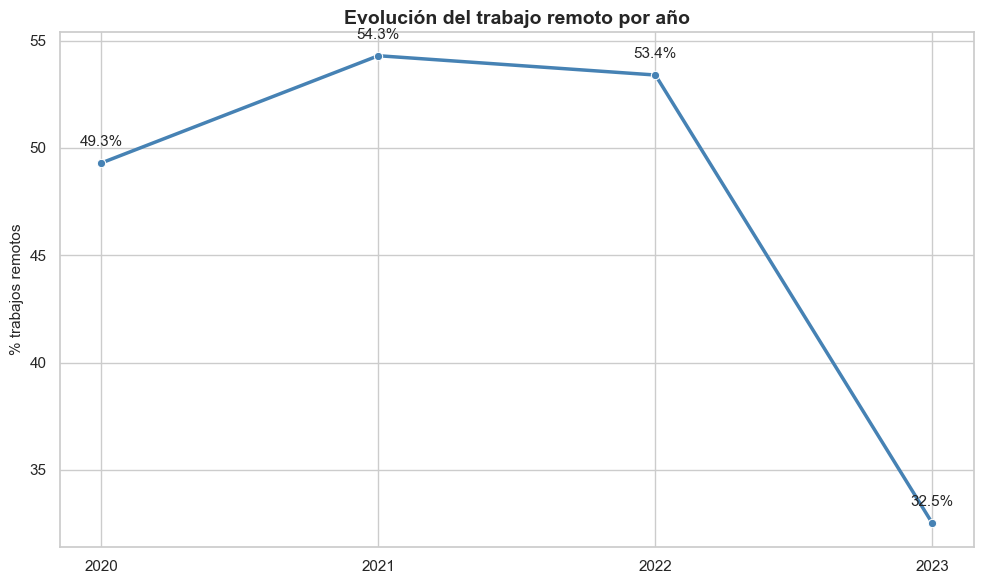

In [7]:
# Obtenemos los datos
data = remote_trend_by_year(df)

# Creamos la figura
fig, ax = plt.subplots()

# Gráfico de línea
sns.lineplot(data=data, x='work_year', y='pct_remote', ax=ax,
             marker='o', linewidth=2.5, color='steelblue')

# Título y etiquetas
ax.set_title('Evolución del trabajo remoto por año', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('% trabajos remotos', fontsize=11)

# Marcamos el porcentaje en cada punto
for _, row in data.iterrows():
    ax.text(row['work_year'], row['pct_remote'] + 0.8,
            f"{row['pct_remote']}%", ha='center', fontsize=11)

# Forzamos años enteros en eje X
ax.set_xticks(data['work_year'])

# Guardamos
plt.tight_layout()
plt.savefig('../data/processed/charts/remote_trend.png', dpi=150, bbox_inches='tight')
plt.show()